# MOF CO₂ Uptake — R²-Optimized Supervised Pipelines

This notebook follows a **consistent, reproducible pipeline** for the MOF CO₂ uptake task and **optimizes models by R²** (coefficient of determination).

## 0. Import Packages

In [135]:
# basics
import os
import numpy as np
import pprint as pp

# pandas is used to read/process data
import pandas as pd
from ydata_profiling import ProfileReport

# machine learning dependencies
# scaling of data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# train/test split
from sklearn.model_selection import train_test_split
# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# the KRR model
from sklearn.kernel_ridge import KernelRidge
# linear model
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso, ElasticNet, BayesianRidge, RidgeCV, ElasticNetCV
# pipeline to streamline modeling pipelines
from sklearn.pipeline import Pipeline
# principal component analysis
from sklearn.decomposition import PCA
# polynomial kernel
from sklearn.metrics.pairwise import polynomial_kernel
# Dummy model as baseline
from sklearn.dummy import DummyClassifier, DummyRegressor
# Variance Threshold for feature selection
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
# metrics to measure model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, r2_score,
                             mean_absolute_error, mean_squared_error, max_error, mean_absolute_percentage_error)
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor, BaggingRegressor, AdaBoostRegressor, VotingRegressor, StackingRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.base import clone

# save/load models
import joblib

# For the permutation importance implementation
from joblib import Parallel
from joblib import delayed
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array

# plotting
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Linear / kernel / tree models
from sklearn.svm import SVR
from xgboost import XGBRegressor

from MOF_descriptors import geometric_descriptors, linker_descriptors, metalcenter_descriptors, functionalgroup_descriptors, summed_linker_descriptors, summed_metalcenter_descriptors, summed_functionalgroup_descriptors

PRIMARY_SCORER = "r2"  # optimize by R²

print("All the required packages are imported")


All the required packages are imported


## Random Seed (for Reproducibility)

In [136]:
RANDOM_SEED = 32
np.random.seed(RANDOM_SEED)

## 1. Load Data


In [137]:
# Load data locally
DATA_DIR = "../data"
DATA_FILE = os.path.join(DATA_DIR, "train.csv")
df = pd.read_csv(DATA_FILE)
print(f"✅ Loaded data from {DATA_FILE}, shape = {df.shape}")

display(df.head())

✅ Loaded data from ../data\train.csv, shape = (5014, 328)


,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-I-3,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K
0,XAGCUE_clean,0.00,2.87682,6.41175,6.41175,487.410,0.000000,0.0000,0.101882,0.21558,...,2496.0,2784.0,7296.0,10752.0,10752.0,242.0856,523.7232,844.9008,1049.6448,1.266370
1,SOBZEQ_clean,2298.52,5.44324,7.06044,7.04565,0.000,0.738273,0.6363,0.000000,0.00000,...,496.0,632.0,1560.0,2240.0,2544.0,58.2840,130.2840,194.2144,231.0000,8.224130
2,AVAQIX01_clean,0.00,3.61603,5.36267,5.34980,600.353,0.000000,0.0000,0.226377,0.30062,...,672.0,1024.0,2400.0,3040.0,2688.0,91.7328,204.2656,276.2848,265.7760,3.694178
3,INURIS_clean,0.00,3.09799,5.07769,4.57779,253.440,0.000000,0.0000,0.077296,0.09856,...,2640.0,3840.0,9264.0,12720.0,13728.0,301.4544,713.6976,1037.0160,1127.9280,1.007227
4,KEDNOY_clean,0.00,3.63243,4.98967,4.98020,519.714,0.000000,0.0000,0.238159,0.28890,...,528.0,864.0,1920.0,2064.0,1920.0,72.0852,153.0144,199.7088,218.5200,3.617103


## Define `FEATURES` and `TARGET`

In [138]:
TARGET = "CO2 uptake at 0.15 bar and 298K"
FEATURES = (
    geometric_descriptors
    + summed_functionalgroup_descriptors
    + summed_linker_descriptors
    + summed_metalcenter_descriptors
)

print("TARGET:", TARGET)
print("FEATURES (count):", len(FEATURES))

TARGET: CO2 uptake at 0.15 bar and 298K
FEATURES (count): 164


## 2. Cleaning — remove duplicates & redundant columns


In [139]:
# Remove duplicates
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. New shape: {df.shape}")

# Remove rows with NaN values
before = df.shape[0]
df = df.dropna()
after = df.shape[0]
print(f"Removed {before - after} rows with NaN values. New shape: {df.shape}")

# Drop constant columns
constant_cols = [c for c in FEATURES if df[c].nunique(dropna=False) <= 1]
if constant_cols:
    print("Dropping constant columns:", constant_cols)
    df = df.drop(columns=constant_cols)
    FEATURES = [c for c in FEATURES if c not in constant_cols]

# Drop perfectly duplicated columns
to_drop = []
cols_list = list(FEATURES)
for i in range(len(cols_list)):
    c1 = cols_list[i]
    if c1 in to_drop: 
        continue
    for j in range(i+1, len(cols_list)):
        c2 = cols_list[j]
        if c2 in to_drop:
            continue
        if df[c1].equals(df[c2]):
            to_drop.append(c2)

if to_drop:
    print("Dropping duplicated columns:", to_drop)
    df = df.drop(columns=to_drop)
    FEATURES = [c for c in FEATURES if c not in to_drop]

print("Final FEATURES count after cleaning:", len(FEATURES))

Removed 14 duplicate rows. New shape: (5000, 328)
Removed 1 rows with NaN values. New shape: (4999, 328)
Dropping constant columns: ['sum-D_func-chi-0-all', 'sum-D_func-Z-0-all', 'sum-D_func-I-0-all', 'sum-D_func-I-1-all', 'sum-D_func-I-2-all', 'sum-D_func-I-3-all', 'sum-D_func-T-0-all', 'sum-D_func-S-0-all', 'sum-D_func-alpha-0-all', 'sum-D_lc-chi-0-all', 'sum-D_lc-Z-0-all', 'sum-D_lc-I-0-all', 'sum-D_lc-I-1-all', 'sum-D_lc-I-2-all', 'sum-D_lc-I-3-all', 'sum-D_lc-T-0-all', 'sum-D_lc-S-0-all', 'sum-D_lc-alpha-0-all', 'sum-D_mc_CRY-chi-0-all', 'sum-D_mc_CRY-Z-0-all', 'sum-D_mc_CRY-I-0-all', 'sum-D_mc_CRY-I-1-all', 'sum-D_mc_CRY-I-2-all', 'sum-D_mc_CRY-I-3-all', 'sum-D_mc_CRY-T-0-all', 'sum-D_mc_CRY-S-0-all']
Final FEATURES count after cleaning: 138


## 3. Stratify Splitting

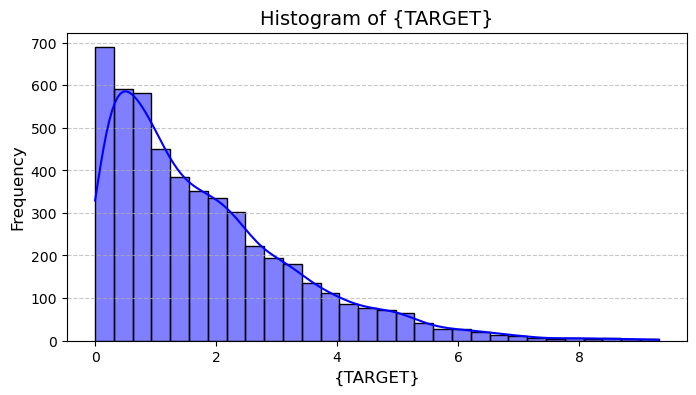

In [140]:
# Plot histogram of the target
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET], kde=True, bins=30, color='blue')

# Add labels and title
plt.xlabel("{TARGET}", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of {TARGET}", fontsize=14)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Based on this histogram and the tail of the distribution, we will use top 10% of the dataset as the threshold for the uptake, thus binarizing our continuous target variable. We use this threshold to define a new column with binary values of 0 and 1 for bad and good materials. 

In [141]:
TARGET_BINARY = "target_binned" # name of the new binary target column
THRESHOLD = df[TARGET].quantile(0.9)  # Top 10% of the dataset
df[TARGET_BINARY] = (df[TARGET] > THRESHOLD).astype(int)

In [142]:
XX = 0.7
YY = 0.3
df_train_stratified, df_test_stratified = train_test_split(
    df,
    train_size=XX,
    test_size=YY,
    random_state=RANDOM_SEED,
    stratify=df[TARGET_BINARY]
)
df_train_stratified.head()

,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,target_binned
1449,HITXUE_clean,0.0000,3.45790,7.01987,7.01987,1103.870,0.000000,0.00000,0.293188,0.42790,...,240.0,384.0,144.0,0.0,39.0624,74.2848,76.7376,0.0000,6.802651,1
3646,RIVDEF_clean,846.5450,4.40879,4.74355,4.74355,0.000,0.203484,0.26552,0.000000,0.00000,...,792.0,1632.0,1740.0,1872.0,65.5656,139.9248,170.5272,167.8104,0.494919,0
4271,RATRUB_clean,896.9290,4.62948,5.58846,5.58392,0.000,0.176560,0.30970,0.000000,0.00000,...,768.0,1800.0,2280.0,1752.0,84.0384,176.4840,253.4376,231.1128,2.452717,0
2207,YOFXEY_clean,17.8535,3.76449,5.28351,3.92047,283.301,0.005462,0.00638,0.102441,0.11966,...,2480.0,6064.0,8272.0,8000.0,191.1560,461.9232,668.5104,676.2112,1.486335,0
4040,KUHVOZ_clean,0.0000,2.54027,6.78369,6.78344,791.845,0.000000,0.00000,0.185781,0.28038,...,1776.0,4176.0,5280.0,4992.0,174.1224,375.1440,522.7680,533.3520,4.445531,1


In [143]:
df_test_stratified.head()

,MOFname,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,...,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,target_binned
3054,WOBQEL_clean,1121.00,5.37096,6.08333,6.07626,0.000,0.354066,0.36838,0.000000,0.00000,...,1704.0,4392.0,6752.0,8288.0,133.4504,328.0200,513.7952,645.8016,5.133429,1
1548,UCOJIH_clean,1604.96,7.11073,8.11816,8.11060,0.000,0.390472,0.47672,0.000000,0.00000,...,3168.0,7776.0,10848.0,11520.0,251.0400,615.7536,891.5712,972.5184,0.584825,0
1084,YEGKOM_clean,1308.57,4.05507,5.20851,5.20188,0.000,0.415991,0.46904,0.000000,0.00000,...,336.0,736.0,832.0,448.0,30.7720,68.6384,84.1536,44.9984,1.025935,0
3296,DACXOV_clean,0.00,3.25603,5.17401,5.17401,508.047,0.000000,0.00000,0.144466,0.20940,...,602.0,1506.0,2176.0,2332.0,48.8734,116.8090,174.4112,196.8848,1.427238,0
361,COQLAX_clean,0.00,0.00000,0.00000,0.00000,456.127,0.000000,0.00000,0.081574,0.10258,...,4620.0,11736.0,17244.0,20352.0,349.3620,877.0608,1334.4060,1620.8448,1.239215,0


## 4. Quick EDA & Target Distribution


Info:
<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 5013
Columns: 303 entries, MOFname to target_binned
dtypes: float64(301), int32(1), object(1)
memory usage: 11.6+ MB

Describe (numeric):


,ASA [m^2/cm^3],Df,Di,Dif,NASA [m^2/cm^3],POAV [cm^3/g],POAVF,PONAV [cm^3/g],PONAVF,density [g/cm^3],...,sum-f-lig-T-0,sum-f-lig-T-1,sum-f-lig-T-2,sum-f-lig-T-3,sum-f-lig-S-0,sum-f-lig-S-1,sum-f-lig-S-2,sum-f-lig-S-3,CO2 uptake at 0.15 bar and 298K,target_binned
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,...,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000,4999.000000
mean,890.891881,4.952574,7.031972,6.942192,141.751504,0.338061,0.292100,0.051973,0.070852,1.293036,...,1097.708342,2765.279456,3796.642128,3961.019404,170.899516,219.169256,520.712459,346.103644,1.798984,0.100020
std,808.654377,2.773695,3.665367,3.600733,264.090934,0.513430,0.256676,0.092246,0.112880,0.467455,...,1136.526740,3133.510724,4459.690366,4815.290040,4509.828206,446.527294,13379.883686,767.336422,1.545871,0.300057
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.063653,...,8.000000,8.000000,0.000000,0.000000,3.081200,4.620000,0.000000,0.000000,0.000027,0.000000
25%,0.000000,3.390940,4.890055,4.834075,0.000000,0.000000,0.000000,0.000000,0.000000,0.998865,...,392.000000,912.000000,1176.000000,1080.000000,39.808800,86.068800,111.537000,113.441900,0.603504,0.000000
50%,888.739000,4.201470,5.898620,5.857930,0.000000,0.223676,0.307240,0.000000,0.000000,1.233370,...,744.000000,1800.000000,2384.000000,2448.000000,64.957000,147.840000,209.387200,229.540800,1.388390,0.000000
75%,1547.015000,5.755400,8.012355,7.899765,184.365000,0.478781,0.501290,0.080555,0.129930,1.534315,...,1410.000000,3534.000000,4974.000000,5308.000000,112.902400,263.141000,388.973600,441.182600,2.579082,0.000000
max,3270.130000,71.501970,71.641190,71.641190,1594.450000,15.098600,0.961060,0.965610,0.581820,4.470600,...,10692.000000,62268.000000,72360.000000,49776.000000,312383.998800,27158.568000,937250.563200,45138.225600,9.318191,1.000000


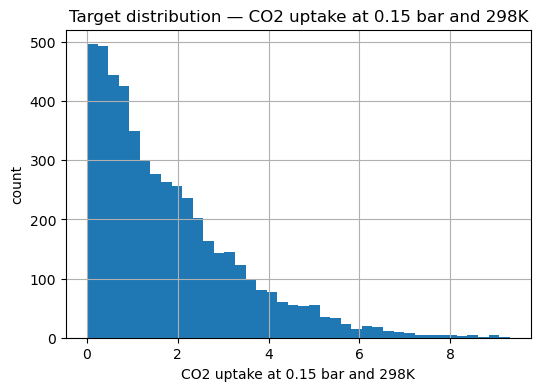

In [144]:
print("Info:")
df.info()

print("\nDescribe (numeric):")
display(df.describe())

plt.figure(figsize=(6,4))
df[TARGET].hist(bins=40)
plt.title(f"Target distribution — {TARGET}")
plt.xlabel(TARGET); plt.ylabel("count")
plt.show()


## Check for any redundancy

In [145]:
redundant_features = [
    col for col in FEATURES 
    if df[col].nunique() <= 1
]

# update feature set
print(f"Number of features before: {len(FEATURES)}")
FEATURES = [feature for feature in FEATURES if not feature in redundant_features]
print(f"Number of features after: {len(FEATURES)}")

Number of features before: 138
Number of features after: 138


## 5. Correlation Analysis (Pearson & Spearman)

Top 10 Pearson correlations with target:
CO2 uptake at 0.15 bar and 298K    1.000000
sum-D_lc-T-1-all                   0.103190
sum-D_mc_CRY-chi-2-all             0.082283
sum-D_mc_CRY-chi-3-all             0.062958
sum-D_func-alpha-1-all             0.062486
sum-D_mc_CRY-chi-1-all             0.054162
sum-D_lc-alpha-1-all               0.044645
sum-D_func-T-1-all                 0.042999
sum-D_func-alpha-3-all             0.033540
sum-func-alpha-0-all               0.032526
Name: CO2 uptake at 0.15 bar and 298K, dtype: float64

Top 10 Spearman correlations with target:
CO2 uptake at 0.15 bar and 298K    1.000000
sum-D_lc-T-1-all                   0.123106
sum-D_lc-alpha-1-all               0.099897
density [g/cm^3]                   0.091090
sum-D_mc_CRY-chi-2-all             0.066394
sum-D_lc-S-1-all                   0.065040
sum-D_func-Z-2-all                 0.051691
sum-D_func-Z-1-all                 0.049374
sum-D_func-Z-3-all                 0.040863
sum-D_func-S-1-all        

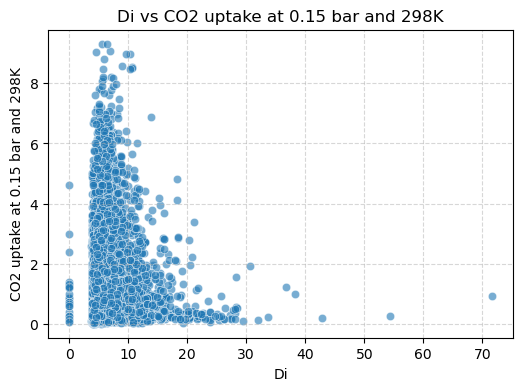

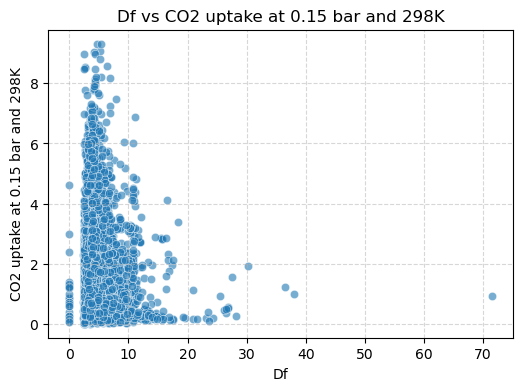

In [146]:
# Pearson correlation (linear relationships)
pearson_corr = df[FEATURES + [TARGET]].corr(method="pearson")[TARGET].sort_values(ascending=False)

# Spearman correlation (monotonic relationships, rank-based)
spearman_corr = df[FEATURES + [TARGET]].corr(method="spearman")[TARGET].sort_values(ascending=False)

print("Top 10 Pearson correlations with target:")
print(pearson_corr.head(10))
print("\nTop 10 Spearman correlations with target:")
print(spearman_corr.head(10))

# Example scatter plots
example_features = ["Density", FEATURES[0], FEATURES[1]]
for feat in example_features:
    if feat in df.columns:
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[feat], y=df[TARGET], alpha=0.6)
        plt.xlabel(feat)
        plt.ylabel(TARGET)
        plt.title(f"{feat} vs {TARGET}")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

## 6. Feature Engineering – Min-Max Normalization

✅ Min-Max scaling applied successfully.
X_train_scaled shape: (3499, 138)
X_valid_scaled shape: (1500, 138)


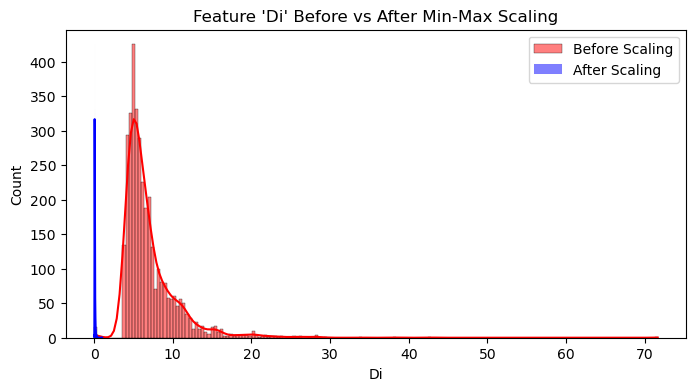

In [147]:
# Initialize scaler
scaler = MinMaxScaler()

# Fit the scaler only on the training data and transform both train and test sets
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(df_train_stratified[FEATURES]),
    columns=FEATURES,
    index=df_train_stratified.index
)

X_valid_scaled = pd.DataFrame(
    scaler.transform(df_test_stratified[FEATURES]),
    columns=FEATURES,
    index=df_test_stratified.index
)

# Keep target columns unchanged
y_train = df_train_stratified[TARGET]
y_valid = df_test_stratified[TARGET]

print("✅ Min-Max scaling applied successfully.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_valid_scaled shape: {X_valid_scaled.shape}")

# Optional: quick comparison plot before vs after scaling
plt.figure(figsize=(8,4))
sns.histplot(df_train_stratified[FEATURES[0]], color='red', label='Before Scaling', kde=True)
sns.histplot(X_train_scaled[FEATURES[0]], color='blue', label='After Scaling', kde=True)
plt.legend()
plt.title(f"Feature '{FEATURES[0]}' Before vs After Min-Max Scaling")
plt.show()


## 7. Feature Engineering - Dimensionality Reduction (PCA)

✅ PCA fitted. Components kept: 17 (to explain ≥95% variance)
Explained variance ratio (first 10 shown): [0.3394 0.1953 0.0918 0.0728 0.0625 0.0413 0.03   0.0268 0.0239 0.0144]
Cumulative explained variance (first 10): [0.3394 0.5346 0.6264 0.6993 0.7618 0.803  0.833  0.8597 0.8836 0.8981]


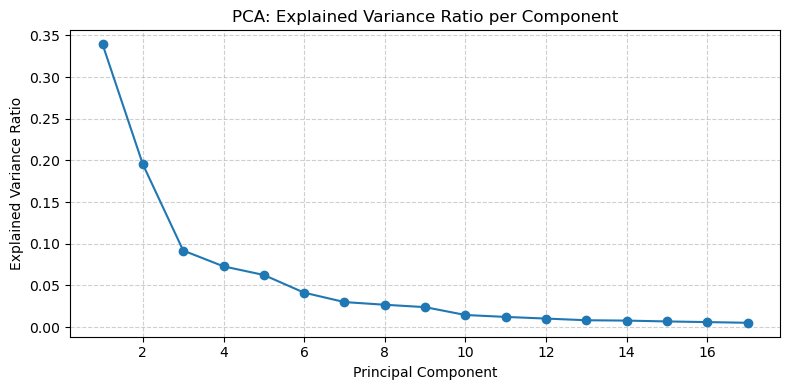

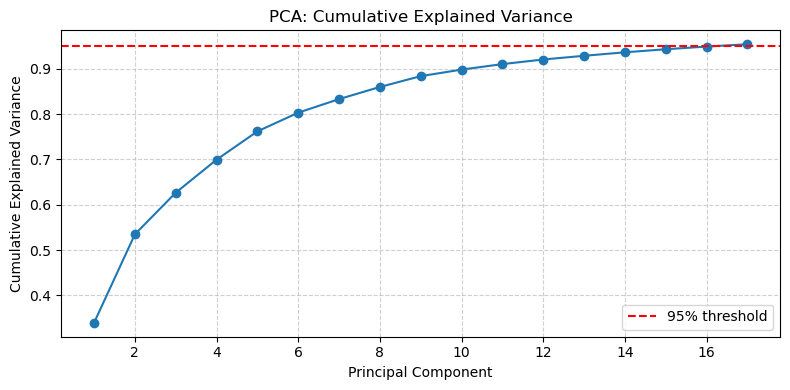

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17
Di,0.183585,0.078872,-0.222867,-0.458496,-0.030948,0.637504,-0.064593,0.218235,-0.163890,0.023864,-0.083965,-0.075753,-0.007835,0.342987,-0.126524,-0.146669,0.001293
Df,0.052876,0.013966,-0.171266,-0.402975,-0.035849,0.597595,-0.060990,0.225177,-0.172334,0.005977,-0.094515,-0.088845,0.004036,0.397294,-0.114471,-0.191776,0.026223
Dif,0.169088,0.071908,-0.216023,-0.450019,-0.024929,0.642564,-0.066018,0.229159,-0.167076,0.017795,-0.087832,-0.073238,-0.009592,0.350870,-0.133333,-0.153821,0.000236
density [g/cm^3],0.044433,-0.012937,0.553922,0.386066,-0.061721,-0.429610,0.046818,-0.179075,0.190515,0.016797,0.024278,-0.077049,-0.021893,0.243225,-0.169125,0.015792,-0.052499
total_SA_volumetric,0.047202,-0.007480,-0.166160,-0.404477,-0.072434,0.532988,-0.054501,0.335855,-0.300715,-0.081939,-0.027932,-0.002182,-0.022288,-0.369523,0.107644,0.274623,0.014849



Top 10 features for PC1:
['sum-mc_CRY-I-2-all', 'sum-mc_CRY-I-1-all', 'sum-mc_CRY-I-3-all', 'sum-mc_CRY-chi-2-all', 'sum-lc-S-2-all', 'sum-lc-Z-2-all', 'sum-lc-chi-2-all', 'sum-mc_CRY-S-3-all', 'sum-D_mc_CRY-S-3-all', 'sum-mc_CRY-S-1-all']

Top 10 features for PC2:
['sum-D_lc-Z-3-all', 'sum-D_mc_CRY-S-2-all', 'sum-D_mc_CRY-Z-2-all', 'sum-D_lc-S-3-all', 'sum-D_lc-Z-1-all', 'sum-func-Z-0-all', 'sum-f-lig-Z-0', 'sum-func-S-0-all', 'sum-func-Z-2-all', 'sum-f-lig-S-0']

Top 10 features for PC3:
['sum-mc_CRY-Z-3-all', 'density [g/cm^3]', 'sum-D_mc_CRY-Z-1-all', 'sum-mc_CRY-Z-0-all', 'sum-func-T-3-all', 'sum-D_mc_CRY-Z-3-all', 'sum-func-I-3-all', 'sum-D_mc_CRY-chi-3-all', 'sum-mc_CRY-T-2-all', 'sum-D_mc_CRY-T-3-all']


In [148]:
# Leak-safe workflow:
#  (1) STANDARDIZE on TRAIN ONLY (even though we already min-maxed),
#  (2) keep components explaining 95% of variance,
#  (3) transform train/valid consistently,
#  and show explained variance + loadings.

# Standardize (fit on train only to avoid leakage)
scaler_pca = StandardScaler(with_mean=True, with_std=True)
Z_train = scaler_pca.fit_transform(X_train_scaled)
Z_valid = scaler_pca.transform(X_valid_scaled)

# PCA keeping 95% variance
pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(Z_train)   # fit on TRAIN
X_valid_pca = pca.transform(Z_valid)       # transform VALID

print(f"✅ PCA fitted. Components kept: {pca.n_components_} (to explain ≥95% variance)")
print("Explained variance ratio (first 10 shown):", np.round(pca.explained_variance_ratio_[:10], 4))
print("Cumulative explained variance (first 10):", np.round(np.cumsum(pca.explained_variance_ratio_[:10]), 4))

# Plots: explained variance ratio and cumulative
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA: Explained Variance Ratio per Component")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(pca.explained_variance_ratio_)+1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA: Cumulative Explained Variance")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Loadings: which original features contribute most to PCs?
# Loadings = components_.T * sqrt(explained_variance_)
# (gives correlation-like importance of each feature to each PC)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, index=X_train_scaled.columns,
                           columns=[f"PC{i+1}" for i in range(pca.n_components_)])
display(loadings_df.head())

# Show top contributors (by absolute loading) for the first 3 PCs
top_k = 10
for i in range(min(3, pca.n_components_)):
    pc = f"PC{i+1}"
    top_feats = (loadings_df[pc].abs().sort_values(ascending=False).head(top_k)).index
    print(f"\nTop {top_k} features for {pc}:")
    print(top_feats.tolist())

# NOTE:
# Use X_train_pca / X_valid_pca in downstream models if you want PCA-based features,
# Use X_train_scaled / X_valid_scaled if you want scaled features.
# Keep y_train / y_valid as defined earlier.

## 8. Baseline with Dummy Regressors (using engineered data)

In [149]:
# Choose which engineered features to use

# Scaled features:
# Xtr_base = X_train_scaled
# Xva_base = X_valid_scaled

# PCA features:
Xtr_base = X_train_pca
Xva_base = X_valid_pca

# Build & fit dummy regressors
dummyregressor_mean   = DummyRegressor(strategy="mean")
dummyregressor_median = DummyRegressor(strategy="median")

dummyregressor_mean.fit(Xtr_base, y_train)
dummyregressor_median.fit(Xtr_base, y_train)

,strategy,'median'
,constant,None
,quantile,None


In [150]:
# Metric: R² (primary) + RMSE/MAE/MAPE for context

def rmse_safe(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def get_regression_metrics(model, X, y_true):
    """Return metrics with R² as the primary metric."""
    y_pred = model.predict(X)
    metrics_dict = {
        "r2":   r2_score(y_true, y_pred),
        "rmse": rmse_safe(y_true, y_pred),
        "mae":  mean_absolute_error(y_true, y_pred),
        "mape": float(np.mean(np.abs((y_true - y_pred) / np.maximum(1e-8, np.abs(y_true)))))
    }
    return metrics_dict
    
dummy_regressors = [
    ("mean",   dummyregressor_mean),
    ("median", dummyregressor_median),
]

In [151]:
# Evaluate on train/valid with engineered features
dummy_results_train = {}
dummy_results_valid = {}

for name, reg in dummy_regressors:
    dummy_results_train[name] = get_regression_metrics(reg, Xtr_base, y_train)
    dummy_results_valid[name] = get_regression_metrics(reg, Xva_base, y_valid)

# Pretty print (R² primary)
print("Dummy Regressor Results — using engineered features")
for split_name, results in [("TRAIN", dummy_results_train), ("VALID", dummy_results_valid)]:
    print(f"\n[{split_name}]")
    for name, m in results.items():
        print(f"{name:>8s} | R2={m['r2']:.4f}  RMSE={m['rmse']:.4f}  MAE={m['mae']:.4f}  MAPE={m['mape']:.4f}")

Dummy Regressor Results — using engineered features

[TRAIN]
    mean | R2=0.0000  RMSE=1.5519  MAE=1.2109  MAPE=22.5482
  median | R2=-0.0650  RMSE=1.6016  MAE=1.1747  MAPE=17.5784

[VALID]
    mean | R2=-0.0001  RMSE=1.5312  MAE=1.2114  MAPE=3.3521
  median | R2=-0.0630  RMSE=1.5787  MAE=1.1615  MAPE=2.5900


## 9. Config, helpers, and a toggle for features (scaled vs PCA)

In [152]:
# Primary scorer: R² (maximize)
PRIMARY_SCORER = "r2"
CV_FOLDS = 5
N_JOBS = -1
RANDOM_SEED = 42

# Keep compute light by default
N_ITER_TUNE = 12     # <-- increase to 30–60 for more thorough tuning
VERBOSE_TUNE = 1

def rmse_safe(y_true, y_pred):
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

def print_scores(name, y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    rmse = rmse_safe(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:>16s} | R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return r2, rmse, mae

# Choose engineered feature set:
USE_PCA = True   # set True to use PCA features from Cell 14

if not USE_PCA:
    Xtr = X_train_scaled
    Xva = X_valid_scaled
else:
    Xtr = X_train_pca
    Xva = X_valid_pca

print("Feature matrix shapes:", Xtr.shape, Xva.shape)

Feature matrix shapes: (3499, 17) (1500, 17)


## 10. Model registry (factories + light param spaces)

In [153]:
# Optional boosters (wrap in try so the cell runs even if not installed)
HAVE_XGB = HAVE_LGBM = HAVE_CAT = False
try:
    from xgboost import XGBRegressor
    HAVE_XGB = True
except Exception:
    pass
try:
    from lightgbm import LGBMRegressor
    HAVE_LGBM = True
except Exception:
    pass
try:
    from catboost import CatBoostRegressor
    HAVE_CAT = True
except Exception:
    pass

def fam_linear():
    return [
        ("LinearRegression", LinearRegression(), {}),
        ("Ridge", Ridge(random_state=RANDOM_SEED), {
            "alpha": np.logspace(-4, 3, 15)
        }),
        ("Lasso", Lasso(random_state=RANDOM_SEED, max_iter=10000), {
            "alpha": np.logspace(-5, 1, 15)
        }),
        ("ElasticNet", ElasticNet(random_state=RANDOM_SEED, max_iter=10000), {
            "alpha": np.logspace(-5, 1, 12),
            "l1_ratio": np.linspace(0, 1, 8),
        }),
        ("BayesianRidge", BayesianRidge(), {
            "alpha_1": [1e-6, 1e-5, 1e-4],
            "alpha_2": [1e-6, 1e-5, 1e-4],
            "lambda_1": [1e-6, 1e-5, 1e-4],
            "lambda_2": [1e-6, 1e-5, 1e-4],
        }),
    ]

def fam_kernel():
    return [
        ("KernelRidge", KernelRidge(), {
            "alpha": np.logspace(-4, 2, 12),
            "kernel": ["rbf", "laplacian", "poly", "sigmoid"],
            "gamma": np.logspace(-5, 0, 10),
            "degree": [2, 3, 4],
            "coef0": np.linspace(0, 2, 5),
        }),
        ("SVR", SVR(), {
            "kernel": ["rbf","poly","sigmoid"],
            "C": np.logspace(-2, 2, 10),
            "gamma": np.logspace(-5, 0, 8),
            "epsilon": np.logspace(-4, -1, 6),
            "degree": [2,3,4],
            "coef0": np.linspace(0, 2, 5),
        }),
        ("GaussianProcess", GaussianProcessRegressor(random_state=RANDOM_SEED), {
        }),
    ]

def fam_instance():
    return [
        ("KNN", KNeighborsRegressor(), {
            "n_neighbors": [3,5,7,11,15],
            "weights": ["uniform","distance"],
            "p": [1,2],  # Manhattan vs Euclidean
        })
    ]

def fam_tree():
    return [
        ("DecisionTree", DecisionTreeRegressor(random_state=RANDOM_SEED), {
            "max_depth": [None, 4, 6, 8, 12],
            "min_samples_split": [2,5,10],
            "min_samples_leaf": [1,2,4],
            "max_features": ["sqrt","log2", None],
        })
    ]

def fam_ensembles():
    return [
        ("RandomForest", RandomForestRegressor(random_state=RANDOM_SEED), {
            "n_estimators": [300, 500, 800],  # increase to [800,1200,1600] for more
            "max_depth": [None, 8, 12],
            "min_samples_split": [2,5,10],
            "min_samples_leaf": [1,2,4],
            "max_features": ["sqrt","log2", None],
            "bootstrap": [True],
        }),
        ("ExtraTrees", ExtraTreesRegressor(random_state=RANDOM_SEED), {
            "n_estimators": [400, 800, 1200],
            "max_depth": [None, 8, 12],
            "min_samples_split": [2,5,10],
            "min_samples_leaf": [1,2,4],
            "max_features": ["sqrt","log2", None],
        }),
    ]

def fam_bagging():
    # use the new parameter name "estimator" (scikit-learn ≥1.2)
    try:
        return [
            ("Bagging (DT base)", BaggingRegressor(
                estimator=DecisionTreeRegressor(random_state=RANDOM_SEED),
                random_state=RANDOM_SEED
            ), {
                "n_estimators": [50, 100, 200],
                "max_samples": [0.5, 0.7, 1.0],
                "max_features": [0.5, 0.7, 1.0],
            })
        ]
    except TypeError:
        # fallback for scikit-learn <1.2
        return [
            ("Bagging (DT base)", BaggingRegressor(
                base_estimator=DecisionTreeRegressor(random_state=RANDOM_SEED),
                random_state=RANDOM_SEED
            ), {
                "n_estimators": [50, 100, 200],
                "max_samples": [0.5, 0.7, 1.0],
                "max_features": [0.5, 0.7, 1.0],
            })
        ]

def fam_boosting():
    models = []
    models.append(("AdaBoost", AdaBoostRegressor(random_state=RANDOM_SEED), {
        "n_estimators": [200, 400, 800],
        "learning_rate": [0.03, 0.1, 0.3],
    }))
    if HAVE_XGB:
        models.append(("XGB", XGBRegressor(random_state=RANDOM_SEED, tree_method="hist"), {
            "n_estimators": [600, 900, 1200],   # ↑ for more compute
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [4,6,8],
            "min_child_weight": [1,3,5],
            "subsample": [0.7,0.9,1.0],
            "colsample_bytree": [0.7,0.9,1.0],
            "reg_alpha": [0.0, 0.1, 0.5],
            "reg_lambda": [0.5, 1.0, 2.0],
        }))
    if HAVE_LGBM:
        models.append(("LGBM", LGBMRegressor(random_state=RANDOM_SEED), {
            "n_estimators": [800, 1200, 1600],
            "learning_rate": [0.03, 0.05, 0.1],
            "num_leaves": [31, 63, 127],
            "max_depth": [-1, 8, 12],
            "min_child_samples": [10, 20, 50],
            "subsample": [0.7, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.9, 1.0],
            "reg_alpha": [0.0, 0.1, 0.5],
            "reg_lambda": [0.5, 1.0, 2.0],
        }))
    if HAVE_CAT:
        models.append(("CatBoost", 
            # silent logging for lighter runs
            __import__("catboost").catboost.CatBoostRegressor(random_state=RANDOM_SEED, loss_function="RMSE", verbose=False),
            {
                "iterations": [800, 1200],
                "depth": [6, 8, 10],
                "learning_rate": [0.03, 0.05],
                "l2_leaf_reg": [1, 3, 5, 7],
            }
        ))
    return models

def fam_neural():
    return [
        ("MLP", MLPRegressor(random_state=RANDOM_SEED, max_iter=600), {
            "hidden_layer_sizes": [(64,), (128,), (64,64)],
            "alpha": np.logspace(-5, -1, 5),        # L2 regularization
            "learning_rate_init": [1e-3, 5e-4],     # keep small to be stable
        })
    ]

FAMILIES = {
    "Linear & Kernel": fam_linear() + fam_kernel(),
    "Instance-based": fam_instance(),
    "Tree-based": fam_tree(),
    "Ensembles": fam_ensembles(),
    "Bagging": fam_bagging(),
    "Boosting": fam_boosting(),
    "Neural Nets": fam_neural(),
    "Probabilistic": [("BayesianRidge (dup)", BayesianRidge(), {})],  # already in Linear; example placeholder
}

print("Families & counts:", {k: len(v) for k,v in FAMILIES.items()})

Families & counts: {'Linear & Kernel': 8, 'Instance-based': 1, 'Tree-based': 1, 'Ensembles': 2, 'Bagging': 1, 'Boosting': 2, 'Neural Nets': 1, 'Probabilistic': 1}


## Light tuner (RandomizedSearchCV) and runner

In [154]:
def tune_one(name, estimator, param_dist, X, y):
    # If no param space, just fit the default model.
    if not param_dist:
        est = estimator
        est.fit(X, y)
        return est, None, None
    search = RandomizedSearchCV(
        estimator=estimator,
        param_distributions=param_dist,
        n_iter=N_ITER_TUNE,
        scoring=PRIMARY_SCORER,
        cv=KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED),
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED,
        verbose=VERBOSE_TUNE,
        refit=True,
    )
    search.fit(X, y)
    return search.best_estimator_, search.best_params_, search.best_score_

def run_family(family_name, models):
    rows = []
    fitted = {}
    print(f"\n=== {family_name} ===")
    for name, estimator, param_dist in models:
        print(f"\n> Tuning {name} (light mode)")
        best_est, best_params, cv_r2 = tune_one(name, estimator, param_dist, Xtr, y_train)
        # Evaluate on VALID
        y_pred = best_est.predict(Xva)
        r2, rmse, mae = print_scores(name, y_valid, y_pred)
        rows.append({
            "family": family_name, "model": name,
            "R2_valid": r2, "RMSE_valid": rmse, "MAE_valid": mae,
            "R2_cv_best": cv_r2, "best_params": best_params
        })
        fitted[name] = best_est
    df_family = pd.DataFrame(rows).sort_values("R2_valid", ascending=False).reset_index(drop=True)
    display(df_family)
    return df_family, fitted

all_results = []
all_fitted = {}
for fam, models in FAMILIES.items():
    df_res, fit = run_family(fam, models)
    all_results.append(df_res)
    all_fitted.update(fit)

leaderboard = pd.concat(all_results, ignore_index=True).sort_values("R2_valid", ascending=False).reset_index(drop=True)
print("\n=== Global Leaderboard (VALID) — higher R² is better ===")
display(leaderboard.head(20))


=== Linear & Kernel ===

> Tuning LinearRegression (light mode)
LinearRegression | R2=0.0448  RMSE=1.4965  MAE=1.1655

> Tuning Ridge (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
           Ridge | R2=0.0489  RMSE=1.4932  MAE=1.1644

> Tuning Lasso (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
           Lasso | R2=0.0454  RMSE=1.4960  MAE=1.1648

> Tuning ElasticNet (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits


c:\Users\mrast\.conda\envs\che1147\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.916e+03, tolerance: 8.427e-01
Linear regression models with a zero l1 penalization strength are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


      ElasticNet | R2=0.0483  RMSE=1.4937  MAE=1.1645

> Tuning BayesianRidge (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
   BayesianRidge | R2=0.0475  RMSE=1.4944  MAE=1.1646

> Tuning KernelRidge (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
     KernelRidge | R2=0.1534  RMSE=1.4088  MAE=1.0918

> Tuning SVR (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
             SVR | R2=0.3134  RMSE=1.2687  MAE=0.8554

> Tuning GaussianProcess (light mode)
 GaussianProcess | R2=-48.9804  RMSE=10.8249  MAE=3.6602


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Linear & Kernel,SVR,0.313409,1.268747,0.855433,0.297901,"{'kernel': 'rbf', 'gamma': 0.03727593720314941..."
1,Linear & Kernel,KernelRidge,0.153405,1.408848,1.091772,0.135882,"{'kernel': 'rbf', 'gamma': 0.00046415888336127..."
2,Linear & Kernel,Ridge,0.048931,1.493249,1.164436,0.061695,{'alpha': 1000.0}
3,Linear & Kernel,ElasticNet,0.048331,1.493719,1.164480,0.060496,"{'l1_ratio': 0.0, 'alpha': 0.2310129700083158}"
4,Linear & Kernel,BayesianRidge,0.047514,1.494361,1.164636,0.060230,"{'lambda_2': 1e-06, 'lambda_1': 0.0001, 'alpha..."
5,Linear & Kernel,Lasso,0.045376,1.496037,1.164783,0.063365,{'alpha': 0.01}
6,Linear & Kernel,LinearRegression,0.044752,1.496526,1.165518,NaN,None
7,Linear & Kernel,GaussianProcess,-48.980367,10.824950,3.660152,NaN,None



=== Instance-based ===

> Tuning KNN (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
             KNN | R2=0.3766  RMSE=1.2090  MAE=0.8514


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Instance-based,KNN,0.376565,1.208988,0.851376,0.374659,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."



=== Tree-based ===

> Tuning DecisionTree (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
    DecisionTree | R2=0.1139  RMSE=1.4413  MAE=1.0823


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Tree-based,DecisionTree,0.11393,1.441319,1.082267,0.12205,"{'min_samples_split': 10, 'min_samples_leaf': ..."



=== Ensembles ===

> Tuning RandomForest (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
    RandomForest | R2=0.4333  RMSE=1.1527  MAE=0.8342

> Tuning ExtraTrees (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
      ExtraTrees | R2=0.4377  RMSE=1.1482  MAE=0.8332


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Ensembles,ExtraTrees,0.437685,1.148196,0.833238,0.411403,"{'n_estimators': 400, 'min_samples_split': 2, ..."
1,Ensembles,RandomForest,0.433263,1.152702,0.834174,0.406389,"{'n_estimators': 300, 'min_samples_split': 2, ..."



=== Bagging ===

> Tuning Bagging (DT base) (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bagging (DT base) | R2=0.4275  RMSE=1.1585  MAE=0.8407


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Bagging,Bagging (DT base),0.427525,1.158522,0.840721,0.404647,"{'n_estimators': 200, 'max_samples': 1.0, 'max..."



=== Boosting ===

> Tuning AdaBoost (light mode)
Fitting 5 folds for each of 9 candidates, totalling 45 fits


c:\Users\mrast\.conda\envs\che1147\lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 9 is smaller than n_iter=12. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


        AdaBoost | R2=0.0993  RMSE=1.4532  MAE=1.2013

> Tuning XGB (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
             XGB | R2=0.4561  RMSE=1.1292  MAE=0.7679


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Boosting,XGB,0.456093,1.129246,0.767929,0.441200,"{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp..."
1,Boosting,AdaBoost,0.099324,1.453150,1.201347,0.100556,"{'n_estimators': 200, 'learning_rate': 0.03}"



=== Neural Nets ===

> Tuning MLP (light mode)
Fitting 5 folds for each of 12 candidates, totalling 60 fits
             MLP | R2=0.2854  RMSE=1.2943  MAE=0.9546


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Neural Nets,MLP,0.285429,1.294341,0.954647,0.189973,"{'learning_rate_init': 0.001, 'hidden_layer_si..."



=== Probabilistic ===

> Tuning BayesianRidge (dup) (light mode)
BayesianRidge (dup) | R2=0.0475  RMSE=1.4944  MAE=1.1646


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Probabilistic,BayesianRidge (dup),0.047514,1.494361,1.164636,None,None



=== Global Leaderboard (VALID) — higher R² is better ===


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Boosting,XGB,0.456093,1.129246,0.767929,0.4412,"{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp..."
1,Ensembles,ExtraTrees,0.437685,1.148196,0.833238,0.411403,"{'n_estimators': 400, 'min_samples_split': 2, ..."
2,Ensembles,RandomForest,0.433263,1.152702,0.834174,0.406389,"{'n_estimators': 300, 'min_samples_split': 2, ..."
3,Bagging,Bagging (DT base),0.427525,1.158522,0.840721,0.404647,"{'n_estimators': 200, 'max_samples': 1.0, 'max..."
4,Instance-based,KNN,0.376565,1.208988,0.851376,0.374659,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
5,Linear & Kernel,SVR,0.313409,1.268747,0.855433,0.297901,"{'kernel': 'rbf', 'gamma': 0.03727593720314941..."
6,Neural Nets,MLP,0.285429,1.294341,0.954647,0.189973,"{'learning_rate_init': 0.001, 'hidden_layer_si..."
7,Linear & Kernel,KernelRidge,0.153405,1.408848,1.091772,0.135882,"{'kernel': 'rbf', 'gamma': 0.00046415888336127..."
8,Tree-based,DecisionTree,0.113930,1.441319,1.082267,0.12205,"{'min_samples_split': 10, 'min_samples_leaf': ..."
9,Boosting,AdaBoost,0.099324,1.453150,1.201347,0.100556,"{'n_estimators': 200, 'learning_rate': 0.03}"


## 11. Models Evaluation - Compare models on multiple metrics

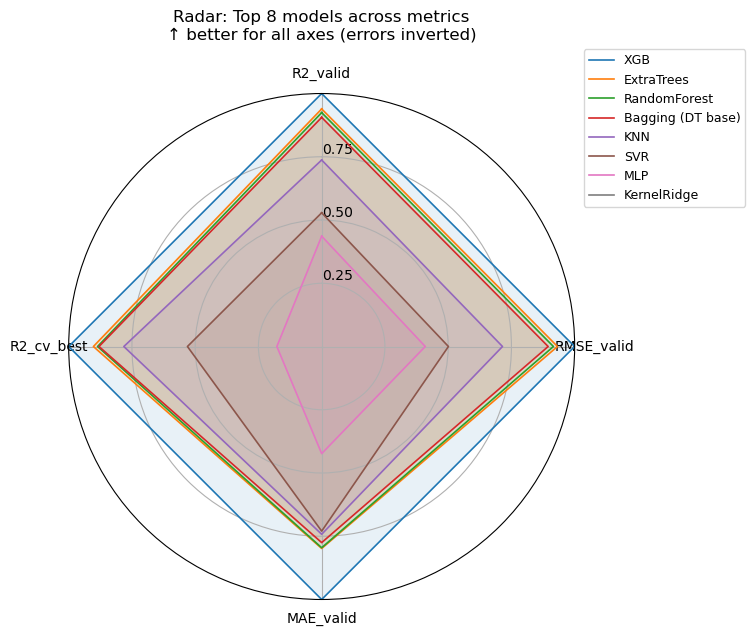

,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best
0,XGB,0.456093,1.129246,0.767929,0.4412
1,ExtraTrees,0.437685,1.148196,0.833238,0.411403
2,RandomForest,0.433263,1.152702,0.834174,0.406389
3,Bagging (DT base),0.427525,1.158522,0.840721,0.404647
4,KNN,0.376565,1.208988,0.851376,0.374659
5,SVR,0.313409,1.268747,0.855433,0.297901
6,MLP,0.285429,1.294341,0.954647,0.189973
7,KernelRidge,0.153405,1.408848,1.091772,0.135882


,R2_valid,RMSE_valid,MAE_valid,R2_cv_best
model,,,,
XGB,1.000000,1.000000,1.000000,1.000000
ExtraTrees,0.939185,0.932225,0.798331,0.902405
RandomForest,0.924576,0.916110,0.795440,0.885983
Bagging (DT base),0.905619,0.895292,0.775226,0.880277
KNN,0.737260,0.714802,0.742322,0.782060
SVR,0.528612,0.501071,0.729796,0.530656
MLP,0.436172,0.409533,0.423431,0.177161
KernelRidge,0.000000,0.000000,0.000000,0.000000


In [155]:
# Metrics: R2_valid (↑ good), RMSE_valid (↓ good), MAE_valid (↓ good), R2_cv_best (↑ good)
# Normalizes metrics so they’re comparable on a 0–1 scale, with directions handled.

# Choose which models to plot
TOP_N = 8
metrics = ["R2_valid", "RMSE_valid", "MAE_valid", "R2_cv_best"]
present = [m for m in metrics if m in leaderboard.columns]
if len(present) < 2:
    raise ValueError(f"Need at least 2 metrics in leaderboard. Found: {present}")

df_plot = leaderboard.head(TOP_N).copy()

# Normalize with direction awareness
# For 'higher is better' metrics: MinMax -> [0..1]
# For 'lower is better' metrics (errors): invert after MinMax so larger = better on the radar
higher_better = {"R2_valid": True, "RMSE_valid": False, "MAE_valid": False, "R2_cv_best": True}

def minmax_scale(series):
    s = series.astype(float)
    lo, hi = np.nanmin(s), np.nanmax(s)
    if np.isclose(hi, lo):
        return np.ones_like(s) * 0.5  # flat metric → draw mid
    return (s - lo) / (hi - lo)

norm_vals = {}
for m in present:
    scaled = minmax_scale(df_plot[m].values)
    if not higher_better.get(m, True):       # invert if lower is better
        scaled = 1.0 - scaled
    # NaNs to middle so plot remains stable
    scaled = np.where(np.isnan(scaled), 0.5, scaled)
    norm_vals[m] = scaled

norm_df = pd.DataFrame(norm_vals, index=df_plot["model"])

# Radar setup
labels = present
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False)
# close the loop
angles = np.concatenate([angles, [angles[0]]])

def radar_values(row):
    vals = row[labels].values.astype(float)
    return np.concatenate([vals, [vals[0]]])

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# grid and labels
ax.set_theta_offset(np.pi / 2)    # start at top
ax.set_theta_direction(-1)        # clockwise
ax.set_thetagrids(angles[:-1] * 180/np.pi, labels)

# radial ticks
ax.set_rlabel_position(0)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(["0.25", "0.50", "0.75"])

# plot each model
for idx, (model_name, row) in enumerate(norm_df.iterrows()):
    values = radar_values(row)
    ax.plot(angles, values, linewidth=1.2, label=f"{model_name}")
    ax.fill(angles, values, alpha=0.10)

title_note = "↑ better for all axes (errors inverted)"
plt.title(f"Radar: Top {len(norm_df)} models across metrics\n{title_note}", pad=20)

plt.legend(loc="upper right", bbox_to_anchor=(1.35, 1.10), fontsize=9)
plt.tight_layout()
plt.show()

# Show the raw numbers alongside normalized values
display(df_plot[["model"] + labels])
display(norm_df)

## Visual comparison plots

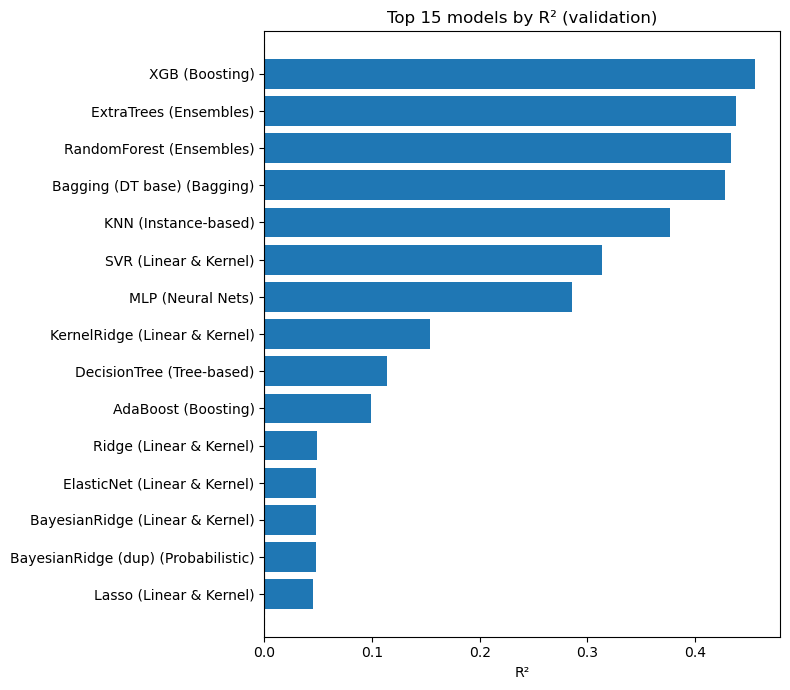


Scatter: top 3 models (by R² on validation)


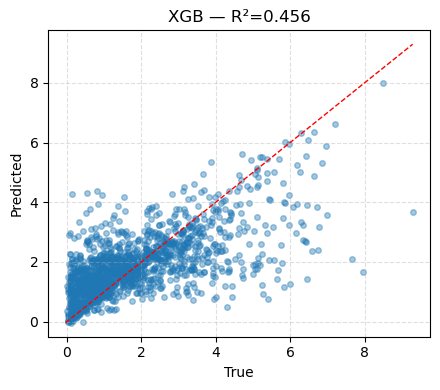

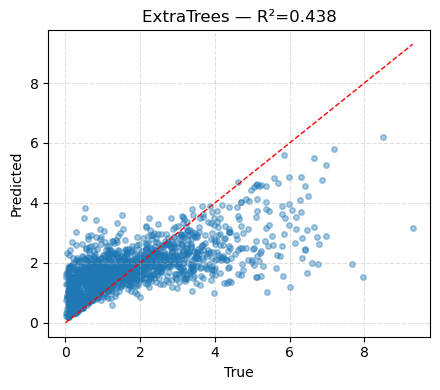

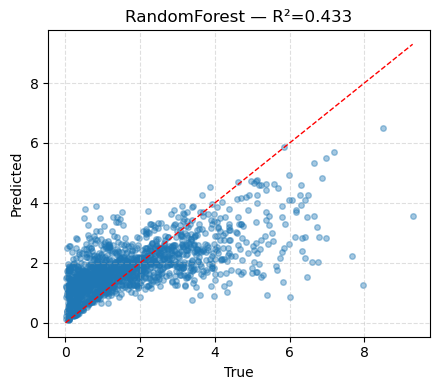

In [156]:
# Barplot of top models by R²
topn = 15
top_models = leaderboard.head(topn).iloc[::-1]  # reverse for horizontal plot

plt.figure(figsize=(8, 0.4*topn + 1))
plt.barh(top_models["model"] + " (" + top_models["family"] + ")", top_models["R2_valid"])
plt.axvline(0.0, color="k", linestyle="--", alpha=0.5)
plt.title(f"Top {topn} models by R² (validation)")
plt.xlabel("R²")
plt.tight_layout()
plt.show()

# y_true vs y_pred scatter for top 3 models
def scatter_pred(est, name, X, y):
    yhat = est.predict(X)
    plt.figure(figsize=(4.5,4))
    plt.scatter(y, yhat, alpha=0.4, s=16)
    lims = [min(y.min(), yhat.min()), max(y.max(), yhat.max())]
    plt.plot(lims, lims, 'r--', lw=1)
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(name)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

print("\nScatter: top 3 models (by R² on validation)")
for i in range(min(3, len(leaderboard))):
    row = leaderboard.iloc[i]
    name = row["model"]
    scatter_pred(all_fitted[name], f"{name} — R²={row['R2_valid']:.3f}", Xva, y_valid)

## Observations
* Best model:	"XGBoost (R² = 0.46)"
* Close contenders:	ExtraTrees, RandomForest, Bagging
* Linear methods:	Too simple — underfitting
* GaussianProcess:	Diverged — ignore unless re-tuned with new kernel

## 12. Refit Best Model on Full Data (optional)

Best on VALID: XGB  | R²_valid = 0.4561
✅ Refit complete on full data.
In-sample R² (sanity): 0.9999


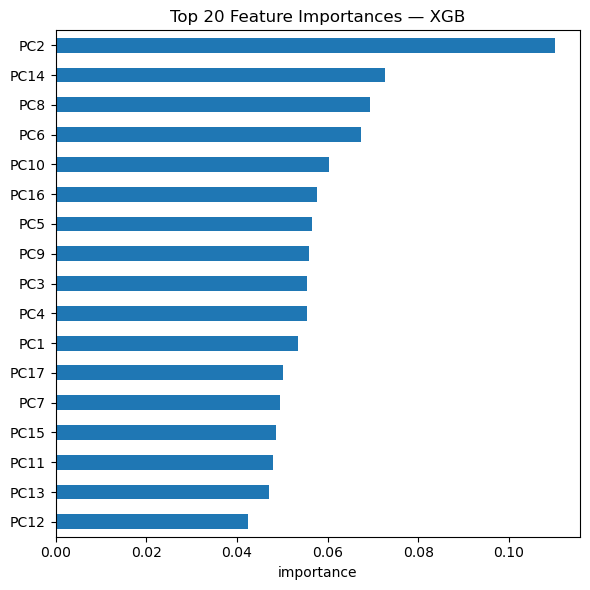

In [157]:
# Select best by validation R²
best_row = leaderboard.iloc[0]
best_name = best_row["model"]
best_est  = all_fitted[best_name]
print(f"Best on VALID: {best_name}  | R²_valid = {best_row['R2_valid']:.4f}")

# Build full training set (engineered features)
X_full = np.vstack([np.asarray(Xtr), np.asarray(Xva)])
y_full = np.concatenate([np.asarray(y_train), np.asarray(y_valid)])

# Refit a fresh clone on ALL data
final_est = clone(best_est)
final_est.fit(X_full, y_full)
print("✅ Refit complete on full data.")
print(f"In-sample R² (sanity): {final_est.score(X_full, y_full):.4f}")


# Quick feature importances (tree/boosting models)
def maybe_plot_importances(estimator, names):
    if names is None:
        return
    importances = getattr(estimator, "feature_importances_", None)
    if importances is None:
        return
    ser = pd.Series(importances, index=names).sort_values(ascending=False).head(20)
    plt.figure(figsize=(6, 6))
    ser.iloc[::-1].plot.barh()
    plt.title(f"Top 20 Feature Importances — {best_name}")
    plt.xlabel("importance")
    plt.tight_layout()
    plt.show()

# Determine feature names for plotting (scaled vs PCA)
if hasattr(Xtr, "columns"):
    feat_names = list(Xtr.columns)
elif globals().get("USE_PCA", False):
    # If PCA, name components as PC1..PCk
    k = X_full.shape[1]
    feat_names = [f"PC{i+1}" for i in range(k)]
else:
    feat_names = None

maybe_plot_importances(final_est, feat_names)

## 13. Top-K Blending (non-negative simplex) + OOF Stacking

In [158]:
# Helpers
def _as_1d(y):
    if isinstance(y, (pd.Series, pd.DataFrame)):
        y = np.asarray(y).ravel()
    return y.ravel()

def _rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(_as_1d(y_true), _as_1d(y_pred)))

def _print_line(name, y_true, y_pred):
    r2  = r2_score(y_true, y_pred)
    rmse = _rmse(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name:>18s} | R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    return r2, rmse, mae

def _pick_top_k(leaderboard_df, all_fitted_dict, k=5):
    # sort by validation R2 (desc), then unique by model name
    lb = leaderboard_df.copy().sort_values("R2_valid", ascending=False)
    names = []
    for _, row in lb.iterrows():
        m = row["model"]
        if m in all_fitted_dict and m not in names:
            names.append(m)
        if len(names) >= k:
            break
    return names

def _maybe_get_Xte():
    # Try to infer the test feature matrix consistently with USE_PCA toggle
    for candidate in ( 
        # PCA route
        "X_test_pca" if "USE_PCA" in globals() and USE_PCA else None,
        # Scaled route
        "X_test_scaled",
        # Raw fallback
        "X_test"
    ):
        if candidate and candidate in globals():
            return globals()[candidate]
    return None

# Configuration
TOP_K = 5  # you can change to 3–6 depending on stability
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# Safety: ensure y are 1D
y_tr_1d = _as_1d(y_train)
y_va_1d = _as_1d(y_valid)

# Select top-k models
top_models = _pick_top_k(leaderboard, all_fitted, k=TOP_K)
print("Top-K models:", top_models)

# Collect validation predictions (for blending)
P_va = []
for name in top_models:
    est_full = all_fitted[name]  # already fitted on Xtr
    P_va.append(est_full.predict(Xva))
P_va = np.column_stack(P_va)  # shape [n_valid, K]

# Find non-negative weights on simplex via coarse grid search
# Simplex grid (step 0.05) — robust and library-free
grid = np.arange(0.0, 1.01, 0.05)
best_rmse = np.inf
best_w = None
K = P_va.shape[1]

def _simplex_combinations(K, step=0.05):
    # recursive generator for K-simplex with sum=1, non-negative, in increments of step
    vals = np.arange(0.0, 1.0 + 1e-9, step)
    if K == 1:
        for v in [1.0]:
            yield np.array([v])
    else:
        def rec(prefix, remaining, depth):
            if depth == K - 1:
                w_last = 1.0 - np.sum(prefix)
                if w_last >= -1e-12:
                    yield np.append(prefix, max(0.0, w_last))
                return
            for v in vals:
                if np.sum(prefix) + v <= 1.0 + 1e-12:
                    yield from rec(np.append(prefix, v), remaining - v, depth + 1)
        yield from rec(np.array([]), 1.0, 0)

for w in _simplex_combinations(K, step=0.05):
    y_blend_va = P_va @ w
    rmse = _rmse(y_va_1d, y_blend_va)
    if rmse < best_rmse:
        best_rmse = rmse
        best_w = w

print("\n=== Top-K Blending (validation) ===")
r2_b, rmse_b, mae_b = _print_line("Blend (val)", y_va_1d, P_va @ best_w)
print("Blend weights (sum=1):", np.round(best_w, 4))

# OOF Stacking
# Build OOF meta-features on Xtr using KFold
OOF = np.zeros((Xtr.shape[0], K))      # OOF preds for train
P_va_stack = np.zeros((Xva.shape[0], K))  # stacked features for validation
P_te_stack = None

Xte = _maybe_get_Xte()
if Xte is not None:
    P_te_stack = np.zeros((Xte.shape[0], K))

for j, name in enumerate(top_models):
    base_full = all_fitted[name]
    base_params = base_full.get_params()
    oof = np.zeros(Xtr.shape[0])
    pva = np.zeros(Xva.shape[0])
    pte = np.zeros(Xte.shape[0]) if Xte is not None else None

    for tr_idx, oof_idx in cv.split(Xtr, y_tr_1d):
        est = clone(base_full).set_params(**base_params)
        est.fit(Xtr[tr_idx], y_tr_1d[tr_idx])
        oof[oof_idx] = est.predict(Xtr[oof_idx])
        pva += est.predict(Xva) / CV_FOLDS
        if Xte is not None:
            pte += est.predict(Xte) / CV_FOLDS

    OOF[:, j] = oof
    P_va_stack[:, j] = pva
    if Xte is not None:
        P_te_stack[:, j] = pte

# Train meta-model on OOF features (regularized to avoid overfit)
meta = RidgeCV(alphas=np.logspace(-4, 3, 20), cv=CV_FOLDS)
meta.fit(OOF, y_tr_1d)

y_stack_va = meta.predict(P_va_stack)
print("\n=== OOF Stacking (validation) ===")
r2_s, rmse_s, mae_s = _print_line("Stack (val)", y_va_1d, y_stack_va)

# Combine blend + stack
y_combo_va = 0.5 * (P_va @ best_w) + 0.5 * y_stack_va
print("\n=== Combined (validation) ===")
_ = _print_line("Combo (val)", y_va_1d, y_combo_va)

Top-K models: ['XGB', 'ExtraTrees', 'RandomForest', 'Bagging (DT base)', 'KNN']

=== Top-K Blending (validation) ===
       Blend (val) | R2=0.4669  RMSE=1.1180  MAE=0.7804
Blend weights (sum=1): [0.6 0.4 0.  0.  0. ]

=== OOF Stacking (validation) ===
       Stack (val) | R2=0.4718  RMSE=1.1128  MAE=0.7778

=== Combined (validation) ===
       Combo (val) | R2=0.4728  RMSE=1.1117  MAE=0.7740


Update leaderboard with Blend / Stack / Combo, and compare via bar plot


=== Updated Leaderboard (VALID) — higher R² is better ===


,family,model,R2_valid,RMSE_valid,MAE_valid,R2_cv_best,best_params
0,Meta-Ensemble,Combo_0.5Blend_0.5Stack,0.472832,1.111734,0.773977,NaN,None
1,Meta-Ensemble,Stack_OOF_RidgeCV,0.471842,1.112777,0.777811,NaN,None
2,Meta-Ensemble,Blend_TopK,0.466882,1.117990,0.780426,NaN,None
3,Boosting,XGB,0.456093,1.129246,0.767929,0.4412,"{'subsample': 0.9, 'reg_lambda': 0.5, 'reg_alp..."
4,Ensembles,ExtraTrees,0.437685,1.148196,0.833238,0.411403,"{'n_estimators': 400, 'min_samples_split': 2, ..."
5,Ensembles,RandomForest,0.433263,1.152702,0.834174,0.406389,"{'n_estimators': 300, 'min_samples_split': 2, ..."
6,Bagging,Bagging (DT base),0.427525,1.158522,0.840721,0.404647,"{'n_estimators': 200, 'max_samples': 1.0, 'max..."
7,Instance-based,KNN,0.376565,1.208988,0.851376,0.374659,"{'weights': 'distance', 'p': 1, 'n_neighbors':..."
8,Linear & Kernel,SVR,0.313409,1.268747,0.855433,0.297901,"{'kernel': 'rbf', 'gamma': 0.03727593720314941..."
9,Neural Nets,MLP,0.285429,1.294341,0.954647,0.189973,"{'learning_rate_init': 0.001, 'hidden_layer_si..."


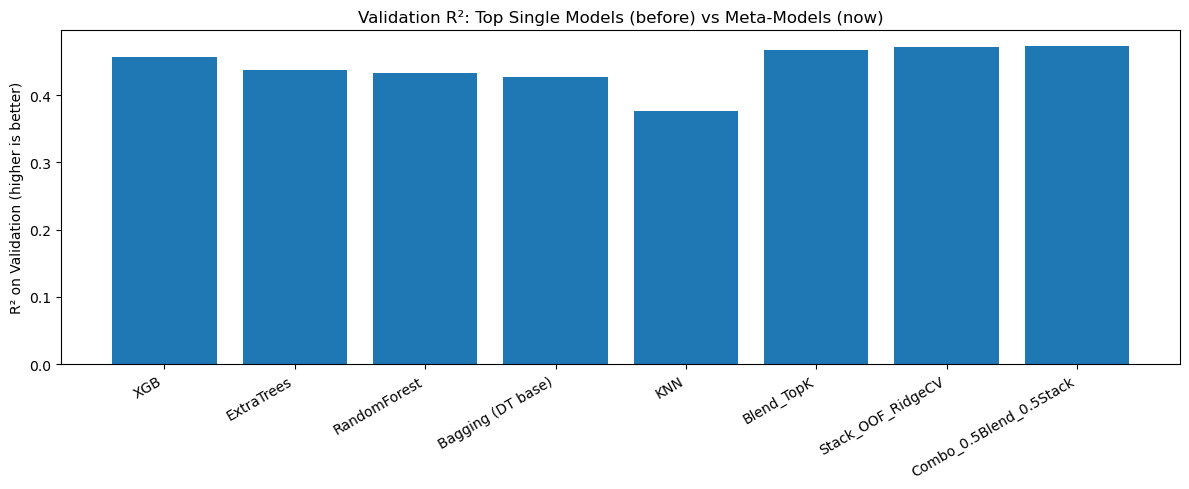

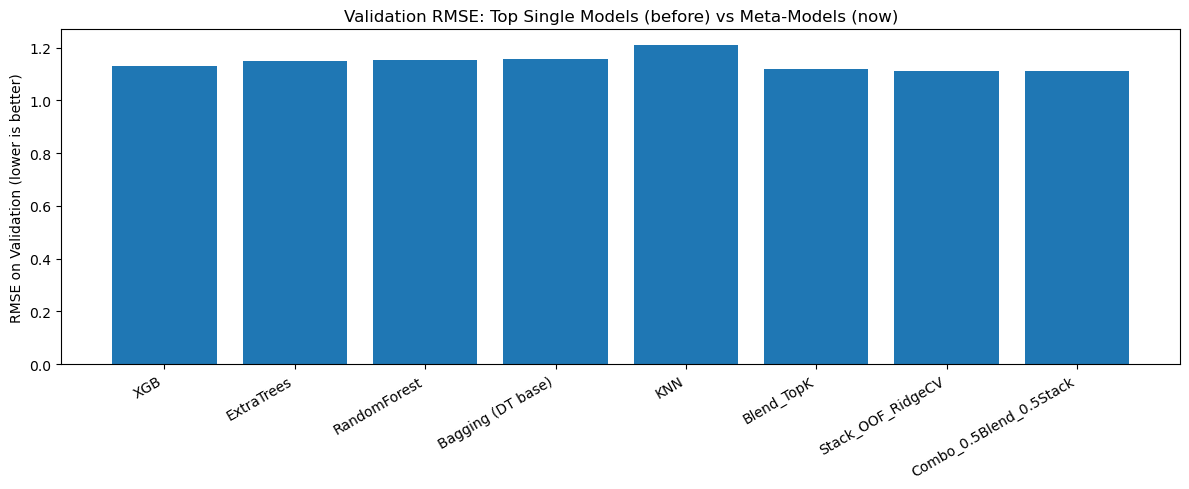


=== Comparison Table (updated) ===


,model,R2_valid,RMSE_valid,MAE_valid,family
0,XGB,0.456093,1.129246,0.767929,Boosting
1,ExtraTrees,0.437685,1.148196,0.833238,Ensembles
2,RandomForest,0.433263,1.152702,0.834174,Ensembles
3,Bagging (DT base),0.427525,1.158522,0.840721,Bagging
4,KNN,0.376565,1.208988,0.851376,Instance-based
5,Blend_TopK,0.466882,1.117990,0.780426,Meta-Ensemble
6,Stack_OOF_RidgeCV,0.471842,1.112777,0.777811,Meta-Ensemble
7,Combo_0.5Blend_0.5Stack,0.472832,1.111734,0.773977,Meta-Ensemble


In [159]:
# Safety: keep a copy of the previous leaderboard (for comparison/record)
old_leaderboard = leaderboard.copy()

# Recompute validation preds to be safe
y_blend_va = P_va @ best_w               # Blend on validation
y_stack_va = y_stack_va
y_combo_va = 0.5 * y_blend_va + 0.5 * y_stack_va

def _as_1d(y):
    return np.asarray(y).ravel()

def _rmse(y_true, y_pred):
    from sklearn.metrics import mean_squared_error
    return np.sqrt(mean_squared_error(_as_1d(y_true), _as_1d(y_pred)))

def _metrics_row(family, name, y_true, y_pred):
    from sklearn.metrics import r2_score, mean_absolute_error
    r2  = r2_score(_as_1d(y_true), _as_1d(y_pred))
    rmse = _rmse(y_true, y_pred)
    mae = mean_absolute_error(_as_1d(y_true), _as_1d(y_pred))
    return {
        "family": family,
        "model": name,
        "R2_valid": r2,
        "RMSE_valid": rmse,
        "MAE_valid": mae,
        "R2_cv_best": np.nan,
        "best_params": None
    }

# Build rows for the new meta-models (validation metrics)
blend_row = _metrics_row("Meta-Ensemble", "Blend_TopK", y_valid, y_blend_va)
stack_row = _metrics_row("Meta-Ensemble", "Stack_OOF_RidgeCV", y_valid, y_stack_va)
combo_row = _metrics_row("Meta-Ensemble", "Combo_0.5Blend_0.5Stack", y_valid, y_combo_va)

# Append and sort
leaderboard = pd.concat(
    [leaderboard, pd.DataFrame([blend_row, stack_row, combo_row])],
    ignore_index=True
).sort_values("R2_valid", ascending=False).reset_index(drop=True)

print("\n=== Updated Leaderboard (VALID) — higher R² is better ===")
display(leaderboard.head(20))

# Comparison Bar Plot
# Choose a compact comparison set:
#   - top 5 single models from the ORIGINAL leaderboard
#   - plus the 3 new meta-models
top5_before = (
    old_leaderboard.sort_values("R2_valid", ascending=False)
    .head(5)["model"]
    .tolist()
)

compare_models = list(dict.fromkeys(top5_before + ["Blend_TopK", "Stack_OOF_RidgeCV", "Combo_0.5Blend_0.5Stack"]))

# Build comparison dataframe using UPDATED leaderboard (so it includes the three new ones)
comp_df = (
    leaderboard[leaderboard["model"].isin(compare_models)]
    .drop_duplicates(subset=["model"])
    .loc[:, ["model", "R2_valid", "RMSE_valid", "MAE_valid", "family"]]
)

# Preserve the order we want
comp_df["order"] = comp_df["model"].apply(lambda m: compare_models.index(m) if m in compare_models else 999)
comp_df = comp_df.sort_values("order").drop(columns="order")

# Plot: R2_valid grouped bar
plt.figure(figsize=(12, 5))
plt.bar(comp_df["model"], comp_df["R2_valid"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("R² on Validation (higher is better)")
plt.title("Validation R²: Top Single Models (before) vs Meta-Models (now)")
plt.tight_layout()
plt.show()

# Plot RMSE (lower is better)
plt.figure(figsize=(12, 5))
plt.bar(comp_df["model"], comp_df["RMSE_valid"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("RMSE on Validation (lower is better)")
plt.title("Validation RMSE: Top Single Models (before) vs Meta-Models (now)")
plt.tight_layout()
plt.show()

# Print a small table too
print("\n=== Comparison Table (updated) ===")
display(comp_df.reset_index(drop=True))


## 14. Save the Best Model

In [160]:
# Pick the best model from the updated leaderboard (highest R² on validation)
best_row = leaderboard.iloc[0]
best_model_name = best_row["model"]
best_family = best_row["family"]

print(f"Best model detected: {best_model_name}  (Family: {best_family})")

# Try to locate it among fitted models
best_model = None

# Meta-models (Blend / Stack / Combo)
if "Blend" in best_model_name:
    print("Saving blended ensemble weights and components...")
    best_model = {"type": "blend", "weights": best_w, "models": top_models}
elif "Stack" in best_model_name:
    print("Saving stacking RidgeCV meta-model and base estimators...")
    best_model = {"type": "stack", "meta_model": meta, "base_models": top_models}
elif "Combo" in best_model_name:
    print("Saving combined Blend + Stack ensemble...")
    best_model = {
        "type": "combo",
        "blend_weights": best_w,
        "meta_model": meta,
        "base_models": top_models,
        "blend_ratio": 0.5,
    }

# Single fitted models
elif best_model_name in all_fitted:
    best_model = all_fitted[best_model_name]
else:
    print("⚠️ Could not find a fitted object for", best_model_name)

# Save model
os.makedirs("models", exist_ok=True)
model_path = f"models/best_{best_model_name.replace(' ', '_')}.pkl"

if best_model is not None:
    joblib.dump(best_model, model_path)
    print(f"✅ Saved best model to: {model_path}")
else:
    print("❌ No model saved. Verify leaderboard and all_fitted contents.")

# Optional: Save leaderboard snapshot
leaderboard.to_csv("models/leaderboard_snapshot.csv", index=False)
print("📄 Leaderboard snapshot saved to models/leaderboard_snapshot.csv")


Best model detected: Combo_0.5Blend_0.5Stack  (Family: Meta-Ensemble)
Saving blended ensemble weights and components...
✅ Saved best model to: models/best_Combo_0.5Blend_0.5Stack.pkl
📄 Leaderboard snapshot saved to models/leaderboard_snapshot.csv


## 15. End-to-end leak-safe pipeline with optional PCA

In [161]:
# Preprocessor builder (mirrors earlier steps)
def make_preprocessor(use_pca=True, pca_var=0.95, random_state=RANDOM_SEED):
    steps = [
        ("minmax", MinMaxScaler()),
        ("standardize", StandardScaler(with_mean=True, with_std=True)),
    ]
    if use_pca:
        steps.append(("pca", PCA(n_components=pca_var, random_state=random_state)))
    return Pipeline(steps)

# Wrap the "best model" into a scikit estimator
def build_best_estimator(best_model_name, leaderboard_df, all_fitted_dict, 
                         top_models=None, blend_weights=None, meta_model=None):
    """
    Returns a scikit-learn estimator that can go inside a Pipeline's 'model' step.
    Handles:
      - Single tuned models (found in all_fitted_dict)
      - Blend_TopK  (VotingRegressor with provided weights)
      - Stack_OOF_RidgeCV (StackingRegressor with RidgeCV meta)
      - Combo_0.5Blend_0.5Stack (averages Blend and Stack)
    """
    # Single fitted model
    if best_model_name in all_fitted_dict:
        base = all_fitted_dict[best_model_name]
        return clone(base).set_params(**base.get_params())

    # Meta: Blend
    if "Blend" in best_model_name:
        assert top_models is not None and blend_weights is not None, "Blend needs top_models & blend_weights"
        estimators = []
        for m in top_models:
            if m not in all_fitted_dict:
                raise ValueError(f"Missing base estimator for {m}")
            estimators.append((m, clone(all_fitted_dict[m]).set_params(**all_fitted_dict[m].get_params())))
        return VotingRegressor(estimators=estimators, weights=list(blend_weights))

    # Meta: Stack
    if "Stack" in best_model_name:
        assert top_models is not None, "Stack needs top_models"
        estimators = []
        for m in top_models:
            if m not in all_fitted_dict:
                raise ValueError(f"Missing base estimator for {m}")
            estimators.append((m, clone(all_fitted_dict[m]).set_params(**all_fitted_dict[m].get_params())))
        final_meta = RidgeCV(alphas=np.logspace(-4, 3, 20), cv=CV_FOLDS) if meta_model is None else clone(meta_model)
        return StackingRegressor(estimators=estimators, final_estimator=final_meta,
                                 passthrough=False, cv=CV_FOLDS, n_jobs=N_JOBS)

    # Meta: Combo (average Blend and Stack 50/50)
    if "Combo" in best_model_name:
        assert top_models is not None and blend_weights is not None, "Combo needs top_models & blend_weights"
        # Inner blend
        estimators_blend = [(m, clone(all_fitted_dict[m]).set_params(**all_fitted_dict[m].get_params()))
                            for m in top_models]
        blend = VotingRegressor(estimators=estimators_blend, weights=list(blend_weights))
        # Inner stack
        estimators_stack = [(m, clone(all_fitted_dict[m]).set_params(**all_fitted_dict[m].get_params()))
                            for m in top_models]
        final_meta = RidgeCV(alphas=np.logspace(-4, 3, 20), cv=CV_FOLDS) if meta_model is None else clone(meta_model)
        stack = StackingRegressor(estimators=estimators_stack, final_estimator=final_meta,
                                  passthrough=False, cv=CV_FOLDS, n_jobs=N_JOBS)
        return VotingRegressor(estimators=[("blend", blend), ("stack", stack)], weights=[1.0, 1.0])

    raise ValueError(f"Don't know how to build estimator for '{best_model_name}'")

# Assemble the full pipeline (preprocessor + best model)
USE_PCA_FOR_PIPE = True  # toggle if you want to try without PCA in the pipeline
preprocessor = make_preprocessor(use_pca=USE_PCA_FOR_PIPE, pca_var=0.95, random_state=RANDOM_SEED)

best_model_name = leaderboard.iloc[0]["model"]
model_estimator = build_best_estimator(
    best_model_name=best_model_name,
    leaderboard_df=leaderboard,
    all_fitted_dict=all_fitted,
    top_models=top_models if "top_models" in globals() else None,
    blend_weights=best_w if "best_w" in globals() else None,
    meta_model=meta if "meta" in globals() else None
)

full_pipeline = Pipeline([
    ("pre", preprocessor),
    ("model", model_estimator),
])

# Sanity fit & validate on the current TRAIN/VALID split
Xtr_raw = df_train_stratified[FEATURES].copy()
Xva_raw = df_test_stratified[FEATURES].copy()

full_pipeline.fit(Xtr_raw, y_train)
yhat_va = full_pipeline.predict(Xva_raw)

r2 = r2_score(y_valid, yhat_va)
rmse = rmse_safe(y_valid, yhat_va)
mae = mean_absolute_error(y_valid, yhat_va)
print(f"Full pipeline @VALID  | R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

Full pipeline @VALID  | R2=0.4669  RMSE=1.1180  MAE=0.7804


## 16. Train best pipeline on Test data

In [162]:
# If 'full_pipeline' is not in memory (e.g., kernel restarted), rebuild it quickly without saving
if 'full_pipeline' not in globals():
    print("ℹ️ full_pipeline not found in memory — rebuilding from leaderboard/all_fitted...")
    preprocessor = make_preprocessor(use_pca=USE_PCA_FOR_PIPE, pca_var=0.95, random_state=RANDOM_SEED)
    best_model_name = leaderboard.iloc[0]["model"]
    model_estimator = build_best_estimator(
        best_model_name=best_model_name,
        leaderboard_df=leaderboard,
        all_fitted_dict=all_fitted,
        top_models=top_models if "top_models" in globals() else None,
        blend_weights=best_w if "best_w" in globals() else None,
        meta_model=meta if "meta" in globals() else None
    )
    full_pipeline = Pipeline([("pre", preprocessor), ("model", model_estimator)])

# 1) Refit on FULL training data (no disk I/O)
X_full_raw = df[FEATURES].copy()
y_full = df[TARGET].copy()
full_pipeline.fit(X_full_raw, y_full)
print("✅ Pipeline refit on FULL training data (in memory).")

# 2) Read test.csv
test_path = os.path.join("..", "data", "test.csv")
test_df = pd.read_csv(test_path)

# 3) Ensure feature columns exist & correct order (add missing as zeros, drop extras)
missing = [c for c in FEATURES if c not in test_df.columns]
if missing:
    print("⚠️ Adding missing test columns with 0:", missing)
    for c in missing:
        test_df[c] = 0.0
X_test_raw = test_df[FEATURES].copy()

# 4) Predict
y_pred = full_pipeline.predict(X_test_raw)

# 5) Build submission with required columns: row_id, MOFname, prediction
#    - row_id: use existing if present; otherwise, create sequential 0..N-1
#row_id_col = None
#for cand in ("row_id", "RowId", "rowID", "id", "ID", "Id"):
#    if cand in test_df.columns:
#        row_id_col = cand
#        break
#row_id_vals = test_df[row_id_col].values if row_id_col is not None else np.arange(len(y_pred))

#    - MOFname: try common spellings; if missing, fill with empty strings
mof_col = None
for cand in ("MOFname", "mof_name", "MOF_name", "mofname"):
    if cand in test_df.columns:
        mof_col = cand
        break
mof_vals = test_df[mof_col].values if mof_col is not None else [""] * len(y_pred)
if mof_col is None:
    print("⚠️ 'MOFname' column not found in test.csv. Filling with empty strings. Update the column name if needed.")

submission = pd.DataFrame({
#     "row_id": row_id_vals,
    "MOFname": mof_vals,
    "CO2 uptake at 0.15 bar and 298K": y_pred
#})[["row_id", "MOFname", "CO2 uptake at 0.15 bar and 298K"]]  # enforce order
})[["MOFname", "CO2 uptake at 0.15 bar and 298K"]]  # enforce order

# 6) Save ONLY the predictions CSV (no model files)
out_path = "submission.csv"
submission.to_csv(out_path, index=False)
print(f"📄 Submission file written to: {out_path}")
display(submission.head())

✅ Pipeline refit on FULL training data (in memory).
📄 Submission file written to: submission.csv


,MOFname,CO2 uptake at 0.15 bar and 298K
0,GEZYOB_clean,1.544882
1,OKAYAC_clean,1.457581
2,WIYWEI_clean,1.585457
3,VUKROK_clean,0.476259
4,IJENER_clean,1.705642
